# Лабораторная работа

**Задача:** прогнозирование временного ряда солнечной активности (количество солнечных пятен).

**Датасет:** `statsmodels.datasets.sunspots` (ежегодное число солнечных пятен).

**Методы прогнозирования:**
1. **ARIMA(11, 0, 0)** — авторегрессионный метод (AR-11, соответствует периоду 11 лет)
2. **Символьная регрессия** (`gplearn.SymbolicRegressor`) — генетическое программирование, поиск математической формулы
3. **МГУА COMBI** (`gmdh.Combi`) — линейный метод перебора комбинаций признаков
4. **МГУА MIA** (`gmdh.Mia`) — нелинейный метод (квадратичные полиномы)

**Метрики:** RMSE, MAE, R²

## 1. Импорты

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set(style='ticks')

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from gplearn.genetic import SymbolicRegressor
import graphviz

import gmdh

## 2. Загрузка и изучение датасета

**Sunspots:**
- 309 значений, без пропусков;
- выраженная квазипериодичность ~11 лет (11-летний солнечный цикл).

In [2]:
raw = sm.datasets.sunspots.load_pandas()
df = raw.data.rename(columns={'YEAR': 'year', 'SUNACTIVITY': 'sunspots'})
df['year'] = df['year'].astype(int)
df = df.set_index('year')

print(f"Размер датасета: {df.shape}")
print(f"Период: {df.index.min()} – {df.index.max()}")
print(f"Пропуски: {df.isnull().sum().sum()}")
df.head(10)

Размер датасета: (309, 1)
Период: 1700 – 2008
Пропуски: 0


,sunspots
year,
1700,5.0
1701,11.0
1702,16.0
1703,23.0
1704,36.0
1705,58.0
1706,29.0
1707,20.0
1708,10.0


In [3]:
df.describe().round(2)

,sunspots
count,309.00
mean,49.75
std,40.45
min,0.00
25%,16.00
50%,40.00
75%,69.80
max,190.20


## 3. Визуализация временного ряда

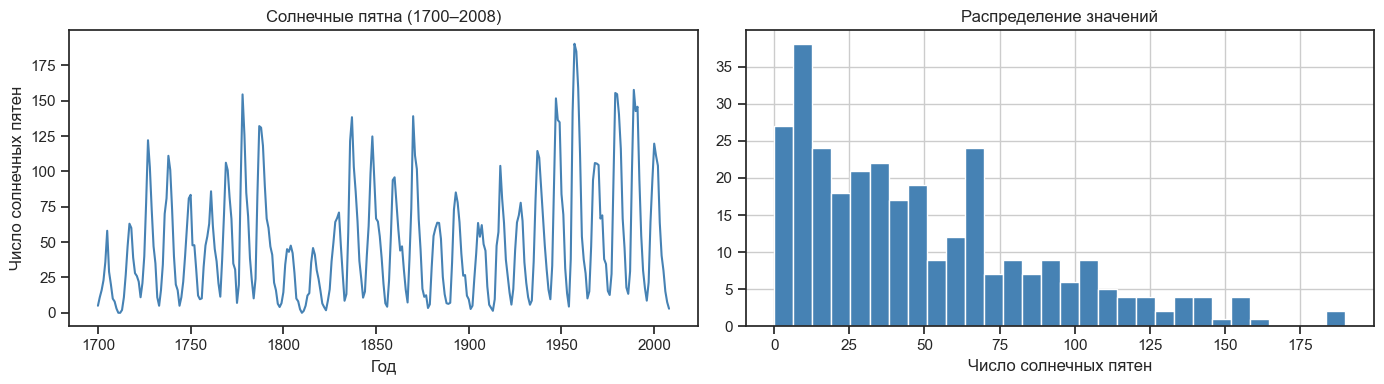

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['sunspots'].plot(ax=axes[0], color='steelblue')
axes[0].set_title('Солнечные пятна (1700–2008)')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Число солнечных пятен')

df['sunspots'].hist(ax=axes[1], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Распределение значений')
axes[1].set_xlabel('Число солнечных пятен')

plt.tight_layout()
plt.show()

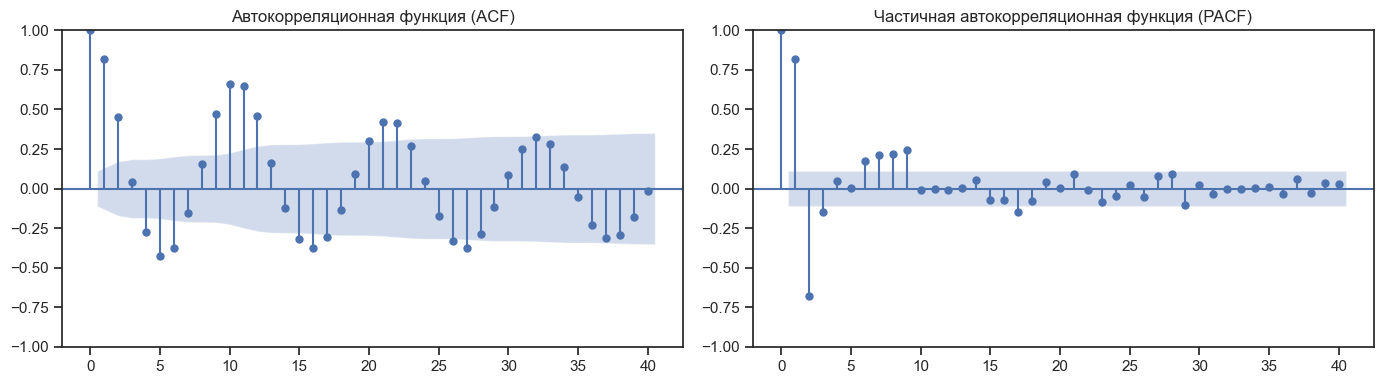

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['sunspots'], lags=40, ax=axes[0])
axes[0].set_title('Автокорреляционная функция (ACF)')
plot_pacf(df['sunspots'], lags=40, ax=axes[1])
axes[1].set_title('Частичная автокорреляционная функция (PACF)')
plt.tight_layout()
plt.show()

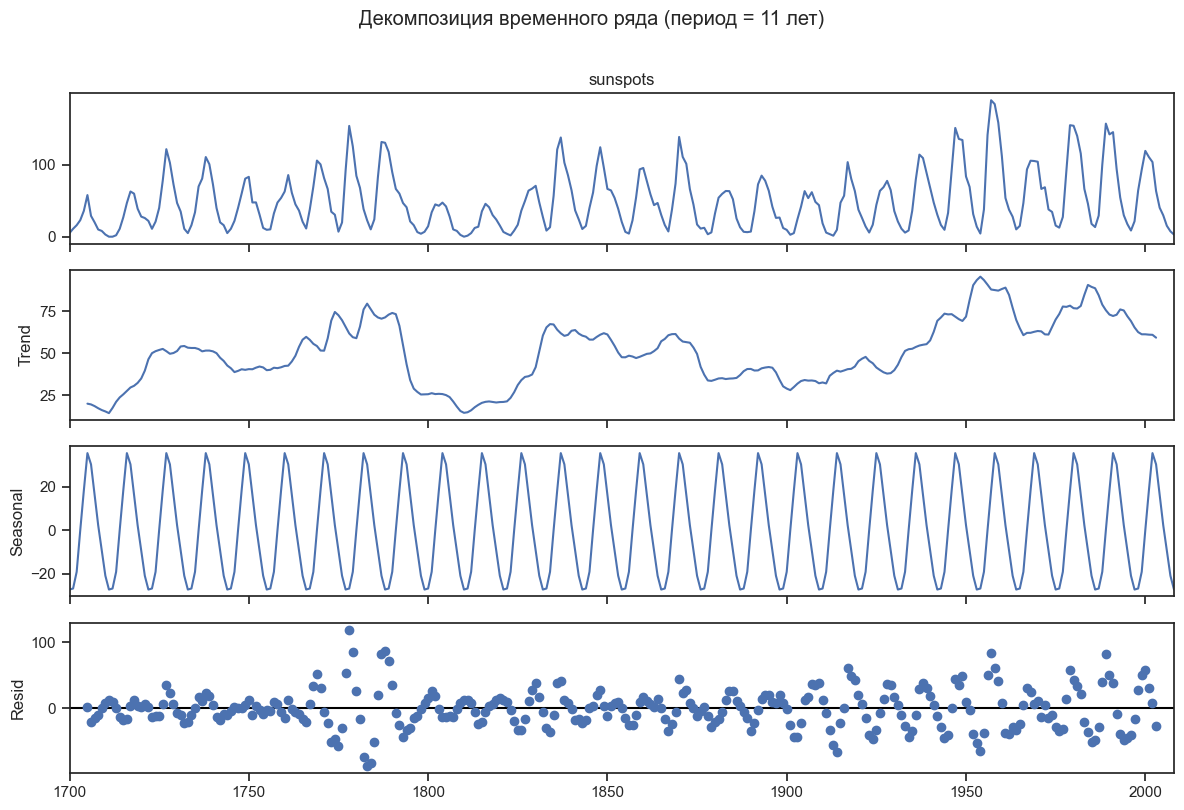

In [6]:
result = seasonal_decompose(df['sunspots'], model='additive', period=11)
fig = result.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Декомпозиция временного ряда (период = 11 лет)', y=1.01)
plt.tight_layout()
plt.show()

## 4. Разделение на обучающую и тестовую выборки

Разбиение по времени: первые 80% точек — обучающая выборка, последние 20% — тестовая выборка.

In [7]:
y = df['sunspots'].values.astype(float)
t = np.arange(len(y))

train_size = int(len(y) * 0.8)
y_train, y_test = y[:train_size], y[train_size:]
t_train, t_test = t[:train_size], t[train_size:]

print(f"Обучающая выборка: {len(y_train)} точек  ({df.index[0]}–{df.index[train_size-1]})")
print(f"Тестовая выборка:  {len(y_test)} точки   ({df.index[train_size]}–{df.index[-1]})")

Обучающая выборка: 247 точек  (1700–1946)
Тестовая выборка:  62 точки   (1947–2008)


In [8]:
p = 11

def make_lag_matrix(series, p):
    X = np.array([series[i : i + p] for i in range(len(series) - p)])
    y_lag = series[p:]
    return X, y_lag


X_all, y_all_lag = make_lag_matrix(y, p)
gmdh_train_size = train_size - p          
X_train_g, y_train_g = X_all[:gmdh_train_size], y_all_lag[:gmdh_train_size]
X_test_g,  y_test_g  = X_all[gmdh_train_size:], y_all_lag[gmdh_train_size:]

scaler = StandardScaler()
X_train_gs = scaler.fit_transform(X_train_g)
X_test_gs  = scaler.transform(X_test_g)

print(f"X_train {X_train_g.shape}, X_test {X_test_g.shape}")

X_train (236, 11), X_test (62, 11)


In [9]:
def print_metrics(y_true, y_pred, model_name=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if model_name:
        print(f'{model_name}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE:  {mae:.4f}')
    print(f'R²:   {r2:.4f}')
    return rmse, mae, r2


predictions = {}

## 5. ARIMA — авторегрессионный метод

Порядок модели **ARIMA(11, 0, 0)** (AR-11) выбран исходя из известной 11-летней периодичности солнечного цикла и пиков на ACF/PACF-графиках.

Прогнозирование ведётся **скользящим окном**: на каждом шаге модель переобучается с добавлением истинного значения (walk-forward validation).

In [10]:
arima_order = (11, 0, 0)
history_arima = list(y_train)
pred_arima = []

for t_step in range(len(y_test)):
    model = ARIMA(history_arima, order=arima_order)
    fit = model.fit()
    yhat = fit.forecast()[0]
    pred_arima.append(yhat)
    history_arima.append(y_test[t_step])

pred_arima = np.array(pred_arima)
predictions['ARIMA(11,0,0)'] = pred_arima

rmse_arima, mae_arima, r2_arima = print_metrics(y_test, pred_arima, 'ARIMA(11,0,0)')

ARIMA(11,0,0)
RMSE: 19.5923
MAE:  15.3010
R²:   0.8622


## 6. Символьная регрессия (gplearn)

Генетическое программирование ищет аналитическую формулу `f(lag1, ..., lag11)` по тем же 11 лаговым признакам, что используются в МГУА.  
Это позволяет напрямую сравнивать символьную регрессию с COMBI/MIA при одинаковых входных данных.

In [11]:
function_set = ['add', 'sub', 'mul', 'div', 'sin', 'cos']

est_gp = SymbolicRegressor(
    population_size=500,
    generations=60,
    stopping_criteria=0.01,
    init_depth=(4, 8),
    function_set=function_set,
    metric='mse',
    const_range=(-10, 10),
    verbose=1,
    random_state=42
)

est_gp.fit(X_train_gs, y_train_g)
pred_gp = est_gp.predict(X_test_gs)
pred_gp = np.clip(pred_gp, 0, None)

predictions['Symbolic Regression'] = pred_gp
print(f'Найденная формула: {est_gp._program}')
print()
rmse_gp, mae_gp, r2_gp = print_metrics(y_test_g, pred_gp, 'Symbolic Regression')

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    31.62      2.57604e+07        6          2414.88              N/A      6.05s
   1    20.05          3632.61        6          2414.88              N/A      4.27s
   2    19.93          3025.37        7          1444.37              N/A      4.30s
   3    11.35           2743.5        9          1224.49              N/A      3.94s
   4    12.53          4005.72       11          1095.53              N/A      3.77s
   5    17.72      4.92989e+07       17          959.227              N/A      3.91s
   6    21.49          4642.61       19          886.329              N/A      3.92s
   7    22.16          13574.1       21          870.637              N/A      3.74s
   8    22.68          30802.1       30          808.358              N/A  

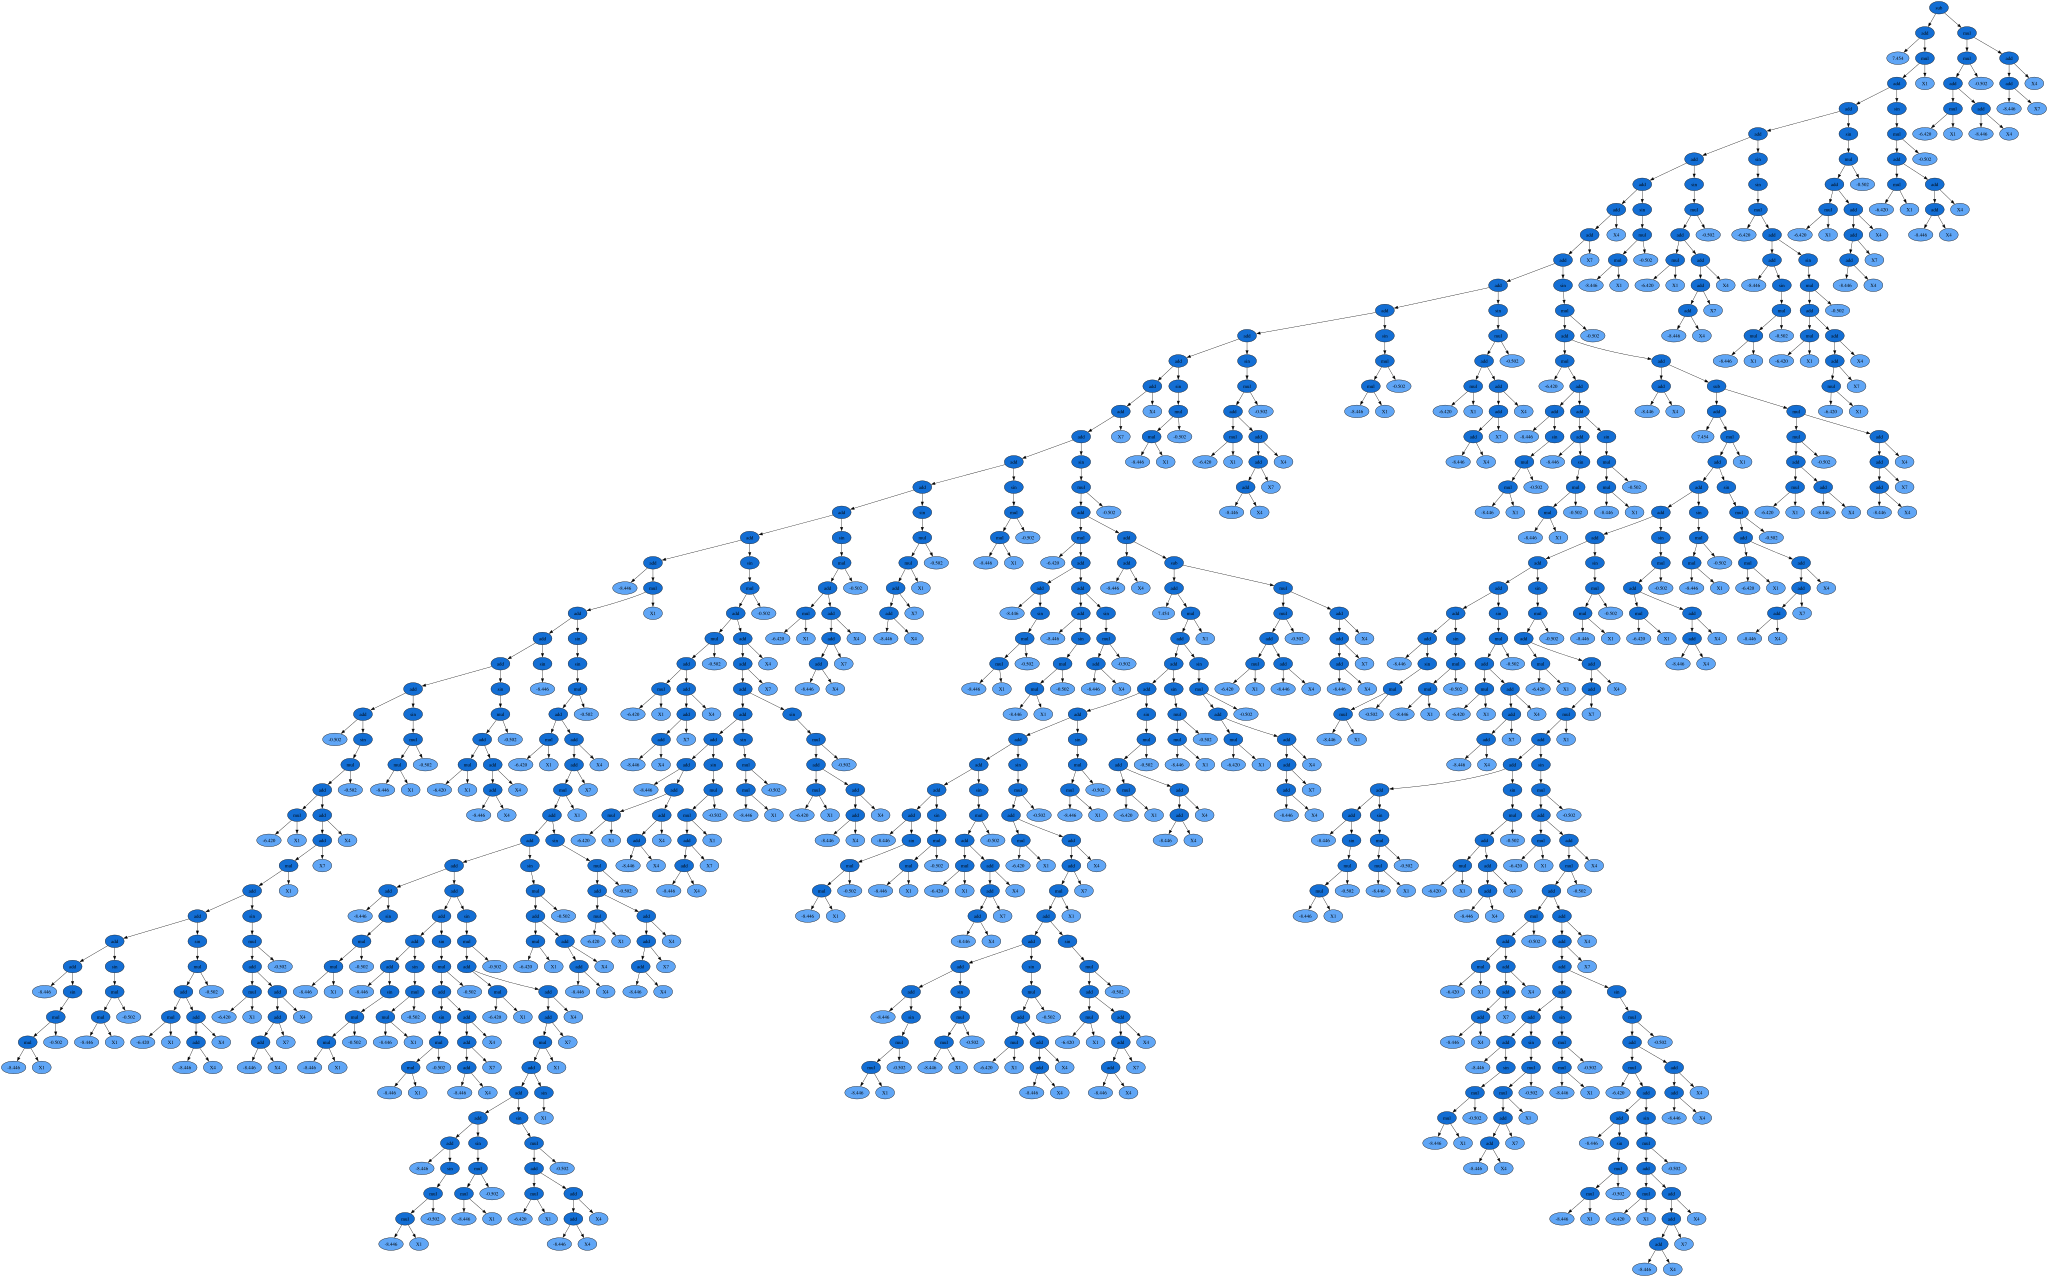

In [12]:
dot_data = est_gp._program.export_graphviz()
graph = graphviz.Source(dot_data)
graph

## 7. МГУА COMBI — линейный метод

**COMBI** — метод группового учёта аргументов с линейными полиномами. На каждом уровне перебирает комбинации пар признаков (лагов), строит линейные полиномы и отбирает лучшие по критерию регулярности.

Признаки: 11 лагов `[y(t−1), y(t−2), ..., y(t−11)]`.

In [13]:
combi_model = gmdh.Combi()
combi_model.fit(
    X_train_gs, y_train_g,
    verbose=1,
    n_jobs=-1,
    criterion=gmdh.Criterion(gmdh.CriterionType.REGULARITY)
)
print()
print('Лучший полином COMBI:')
print(combi_model.get_best_polynomial())
print()

pred_combi = combi_model.predict(X_test_gs)
pred_combi = np.clip(pred_combi, 0, None)

predictions['COMBI'] = pred_combi
rmse_combi, mae_combi, r2_combi = print_metrics(y_test_g, pred_combi, 'COMBI')

LEVEL 1  [>                        ] 0% :00s] (11 combinations)
Лучший полином COMBI:
y = 4.768*x3 + 2.0242*x6 - 3.6837*x7 + 2.4062*x8 - 20.202*x10 + 43.5866*x11 + 44.2792

COMBI
RMSE: 19.5789
MAE:  15.2583
R²:   0.8624
LEVEL 1  [=========================] 100% :00s] (11 combinations) error=51594.227189
LEVEL 2  [=========================] 100% :00s] (55 combinations) error=27217.126986
LEVEL 3  [=========================] 100% :00s] (165 combinations) error=23959.570659
LEVEL 4  [=========================] 100% :00s] (330 combinations) error=23901.295832
LEVEL 5  [=========================] 100% :00s] (462 combinations) error=23790.301011
LEVEL 6  [=========================] 100% :00s] (462 combinations) error=23757.802346
LEVEL 7  [=========================] 100% :00s] (330 combinations) error=23981.913914


## 8. МГУА MIA — нелинейный метод

**MIA** (Multi-Input Approximation) — многоуровневый МГУА с квадратичными полиномами. На каждом слое строит квадратичные полиномы от пар признаков; выходы слоя становятся входами следующего.

In [14]:
mia_model = gmdh.Mia()
mia_model.fit(
    X_train_gs, y_train_g,
    verbose=1,
    n_jobs=-1,
    k_best=5,
    criterion=gmdh.Criterion(gmdh.CriterionType.REGULARITY),
    polynomial_type=gmdh.PolynomialType.QUADRATIC
)
print()

pred_mia = mia_model.predict(X_test_gs)
pred_mia = np.clip(pred_mia, 0, None)

predictions['MIA'] = pred_mia
rmse_mia, mae_mia, r2_mia = print_metrics(y_test_g, pred_mia, 'MIA')

LEVEL 1  [>                        ] 0% :00s] (55 combinations)
MIA
RMSE: 26.8759
MAE:  19.3693
R²:   0.7408
LEVEL 1  [=========================] 100% :00s] (55 combinations) error=20937.122301
LEVEL 2  [=========================] 100% :00s] (10 combinations) error=17889.583544
LEVEL 3  [=========================] 100% :00s] (10 combinations) error=17030.659518
LEVEL 4  [=========================] 100% :00s] (10 combinations) error=17559.533586


## 9. Сравнение моделей

In [15]:
results = pd.DataFrame({
    'Модель': ['ARIMA(11,0,0)', 'Symbolic Regression', 'COMBI', 'MIA'],
    'RMSE': [rmse_arima, rmse_gp, rmse_combi, rmse_mia],
    'MAE':  [mae_arima,  mae_gp,  mae_combi,  mae_mia],
    'R²':   [r2_arima,   r2_gp,   r2_combi,   r2_mia]
})
results = results.sort_values('R²', ascending=False).reset_index(drop=True)
print('Результаты всех моделей:')
results.round(4)

Результаты всех моделей:


,Модель,RMSE,MAE,R²
0,COMBI,19.5789,15.2583,0.8624
1,"ARIMA(11,0,0)",19.5923,15.3010,0.8622
2,MIA,26.8759,19.3693,0.7408
3,Symbolic Regression,40.1867,29.5508,0.4204


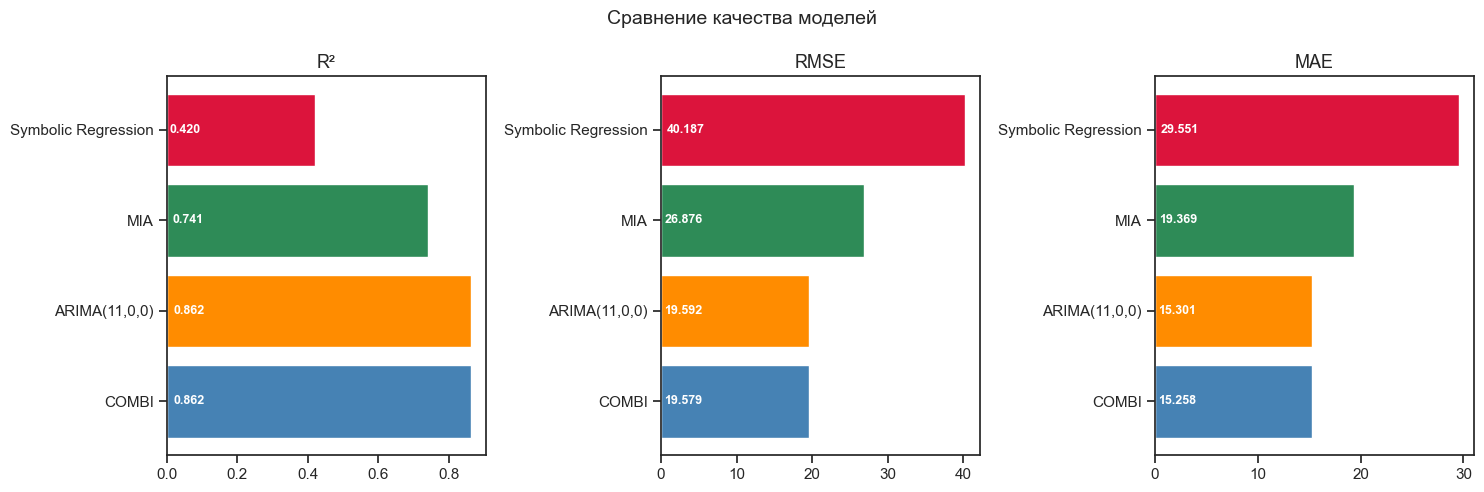

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle('Сравнение качества моделей', fontsize=14)
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for ax, (metric, ascending) in zip(axes, [('R²', False), ('RMSE', True), ('MAE', True)]):
    data_s = results.sort_values(metric, ascending=ascending)
    bars = ax.barh(data_s['Модель'], data_s[metric], color=colors)
    ax.set_title(metric, fontsize=13)
    for bar, val in zip(bars, data_s[metric]):
        ax.text(bar.get_width() * 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

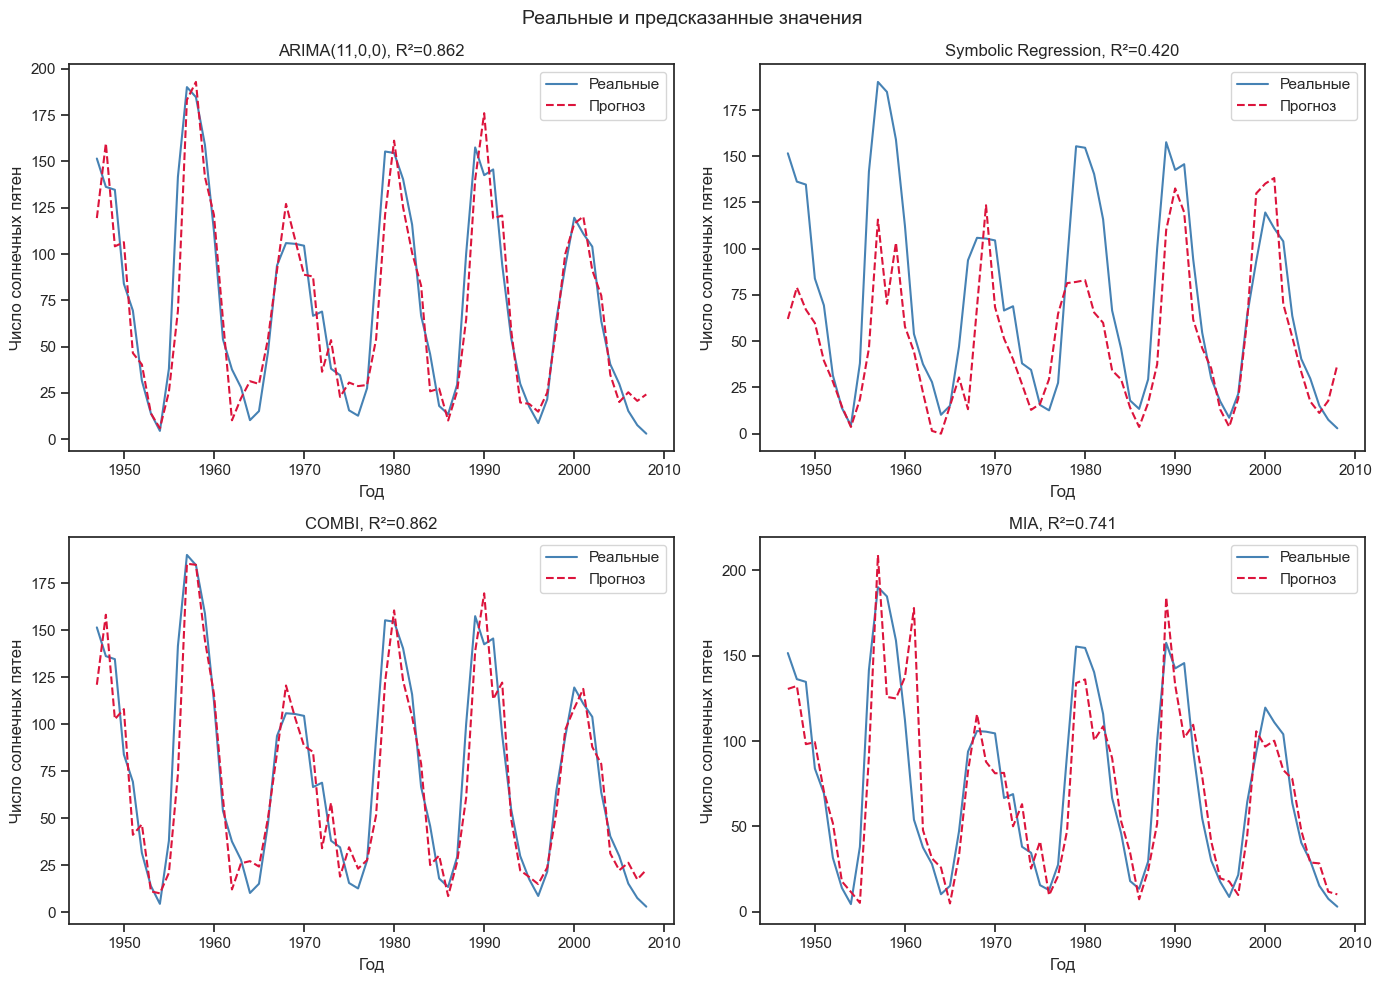

In [17]:
test_years = df.index[train_size:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle('Реальные и предсказанные значения', fontsize=14)

models_info = [
    ('ARIMA(11,0,0)', pred_arima, r2_arima),
    ('Symbolic Regression', pred_gp, r2_gp),
    ('COMBI', pred_combi, r2_combi),
    ('MIA', pred_mia, r2_mia),
]

for ax, (name, pred, r2) in zip(axes.flatten(), models_info):
    ax.plot(test_years, y_test, label='Реальные', color='steelblue', linewidth=1.5)
    ax.plot(test_years, pred,   label='Прогноз',  color='crimson',   linewidth=1.5, linestyle='--')
    ax.set_title(f'{name}, R²={r2:.3f}')
    ax.set_xlabel('Год')
    ax.set_ylabel('Число солнечных пятен')
    ax.legend()

plt.tight_layout()
plt.show()

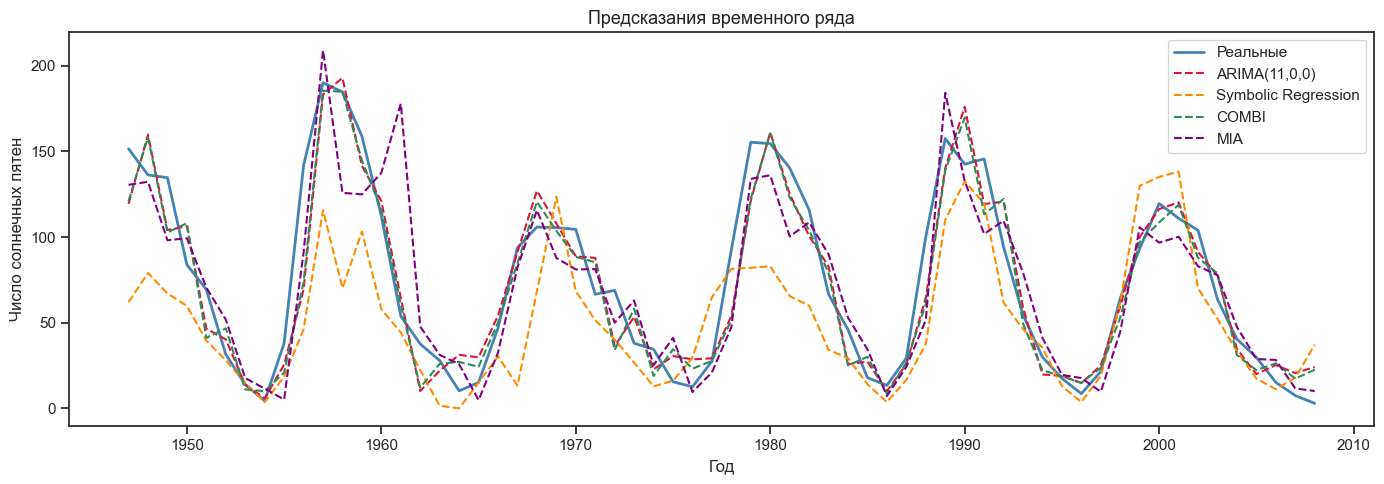

In [18]:
test_years = df.index[train_size:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_years, y_test, label='Реальные', color='steelblue', linewidth=2)
ax.plot(test_years, pred_arima, label='ARIMA(11,0,0)', color='crimson', linewidth=1.5, linestyle='--')
ax.plot(test_years, pred_gp, label='Symbolic Regression', color='darkorange', linewidth=1.5, linestyle='--')
ax.plot(test_years, pred_combi, label='COMBI', color='seagreen', linewidth=1.5, linestyle='--')
ax.plot(test_years, pred_mia, label='MIA', color='purple', linewidth=1.5, linestyle='--')
ax.set_title('Предсказания временного ряда', fontsize=13)
ax.set_xlabel('Год')
ax.set_ylabel('Число солнечных пятен')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Выводы

### Сравнение моделей

| Модель | R² | RMSE | MAE |
|---|---|---|---|
| **ARIMA(11,0,0)** | 0.8622 | 19.59 | 15.30 |
| **COMBI** | 0.8624 | 19.58 | 15.26 |
| **MIA** | 0.7408 | 26.88 | 19.37 |
| **Symbolic Regression** | 0.4204 | 40.19 | 29.55 |

### Наблюдения

- **ARIMA(11, 0, 0)** и **COMBI** показывают практически идентичное качество (R²≈0.862). COMBI автоматически отбирает нужные лаги: `y = 4.77·lag3 + 2.02·lag6 - 3.68·lag7 + 2.41·lag8 - 20.20·lag10 + 43.59·lag11 + 44.28`. Коэффициент при lag11 наибольший — алгоритм самостоятельно обнаружил 11-летний цикл.
- **ARIMA(11, 0, 0)** — авторегрессионная модель, walk-forward валидация которой обновляет историю истинными значениями на каждом шаге, что обеспечивает высокую точность.
- **MIA** уступает COMBI: R²=0.74 против 0.86. Квадратичные взаимодействия добавляют сложность, не улучшая результат — ряд солнечных пятен хорошо описывается линейными зависимостями.
- **Символьная регрессия** (gplearn) занимает последнее место (R²=0.42). Генетический алгоритм находит сложную, трудночитаемую формулу, которая переобучается на обучающей выборке и хуже обобщается на тестовую выборку. Тем не менее, результат лучше наивного прогноза (R²>0).